In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
from datetime import datetime
import os
import seaborn as sb
style.use('fast')
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score  
from statistics import mean

def ROC_PR_AUC_Curves(Values_real,Value_infered, number_genes, file_path_data, algorithm, color_ROC="indigo", color_PR= "springgreen", show_plot=False):
    """
        This functions returns the area under the ROC and PR curve 
        and plots the tpr vs fpr and the precision vs recall.
    """
    
    #ROC
    fpr, tpr, thresholds = roc_curve(Values_real, Value_infered)
    AUC_ROC = auc(fpr, tpr)
    
    
    #PR
    precision, recall, thresholds = precision_recall_curve(Values_real, Value_infered)
    AUC_PR = auc(recall, precision)
    
    if show_plot==True:
        
        plt.rc('xtick', labelsize=22)    
        plt.rc('ytick', labelsize=22)    
        plt.rcParams["font.family"] = "serif"
    
        plt.figure(figsize=(9,7))
        plt.plot([0, 1], [0, 1], 'k--',  lw=2.8)
        plt.plot(fpr, tpr, lw=2.8, color=color_ROC,label='Area = {:.3f}'.format(AUC_ROC))
        plt.fill_between(fpr, tpr,color=color_ROC, alpha=0.28)
        plt.xlabel('False positive rate',family="serif",fontsize = 26)
        plt.ylabel('True positive rate',family="serif",fontsize = 26)
        plt.title(f'ROC {number_genes} Genes, {algorithm}',family="serif",fontsize = 31)
        plt.legend(prop={'size':20, 'family':'serif'},loc='lower right')
        #plt.savefig(f"{file_path_data}/ROC_curve_Genes-{number_genes}.png", bbox_inches="tight", dpi=100 )
        
        plt.figure(figsize=(9,7))
        plt.plot([0, 1], [1, 0], 'k--',  lw=2.8)
        plt.plot(recall, precision, lw=2.8, color=color_PR,label='Area = {:.3f}'.format(AUC_PR))
        plt.fill_between(recall, precision,color=color_PR, alpha=0.28)
        plt.xlabel('Recall',family="serif",fontsize = 26)
        plt.ylabel('Precision',family="serif",fontsize = 26)
        plt.title(f'PRC {number_genes} Genes, {algorithm}',family="serif",fontsize = 31)
        plt.legend(prop={'size':20, 'family':'serif'},loc='lower right')
        #plt.savefig(f"{file_path_data}/PR_curve_Genes-{number_genes}.png", bbox_inches="tight", dpi=100 )
        
    
    return AUC_ROC, AUC_PR

In [2]:
header_list = ["Cause Gene", "Effect Gene", "mean_importance"]
algorithm = "SWING"
Nodes = [10,20]#,50]#, 100]
In_degree = [2,3,4]
Replicates = [10,20,50,100]

ranking = {}
AUROC = {}
AUPRC = {}

for nodes in Nodes:
    
    for replicates in Replicates:
        
        for in_degree in In_degree:
            
            AUROC[f"{algorithm}_{nodes}genes_{in_degree}_{replicates}replicates"] = []
            AUPRC[f"{algorithm}_{nodes}genes_{in_degree}_{replicates}replicates"] = []
            
            #AUROC[f"{algorithm}_{nodes}genes_{in_degree}_{replicates}replicates_rand"] = []
            #AUPRC[f"{algorithm}_{nodes}genes_{in_degree}_{replicates}replicates_rand"] = []
            
            ranking[f"{algorithm}_{nodes}genes_{in_degree}_{replicates}replicates"] = pd.DataFrame()
            #ranking[f"{algorithm}_{nodes}genes_{in_degree}_{replicates}replicates_rand"] = pd.DataFrame()
            
            for instance in range(100):
            
                instance = instance + 1
                
                gold_standard = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/Analysis Replicates/Results_{in_degree}_in/In_out_degree_{in_degree}_nodes_{nodes}/Goldstandards/goldSigned_{instance}_transformed.tsv", sep="\t", names= header_list)
                gold_standard = gold_standard.sort_values(by=["Cause Gene", "Effect Gene"])
                    
                mean_prediction = pd.read_csv(f"Results_{in_degree}_in/Results_{nodes}genes_100insilico_networks/mean_importance_{algorithm}_{instance}_replicates{replicates}.tsv", sep = "\t").sort_values(by=["regulator-target"])
                #mean_prediction_rand = pd.read_csv(f"Results_{in_degree}_in/Results_{nodes}genes_100insilico_networks_rand/mean_importance_{algorithm}_{instance}_replicates{replicates}_rand.tsv", sep = "\t", names = header_list).sort_values(by=["Cause Gene", "Effect Gene"])
                
                ranking[f"{algorithm}_{nodes}genes_{in_degree}_{replicates}replicates"][f"instance{instance}"] = mean_prediction["mean_importance"]
                #ranking[f"{algorithm}_{nodes}genes_{in_degree}_{replicates}replicates_rand"][f"instance{instance}"] = mean_prediction_rand["mean_importance"]
                
                AUROC_value, AUPRC_value = ROC_PR_AUC_Curves(gold_standard["mean_importance"], mean_prediction["mean_importance"] , nodes, "Nothing", f"SWING Run {instance}", show_plot=False)
                #AUROC_value_rand, AUPRC_value_rand = ROC_PR_AUC_Curves(gold_standard["mean_importance"], mean_prediction_rand["mean_importance"], nodes, "Nothing", f"dynGENIE3 Run {instance}", show_plot=False)
                
                AUROC[f"{algorithm}_{nodes}genes_{in_degree}_{replicates}replicates"].append(AUROC_value)
                AUPRC[f"{algorithm}_{nodes}genes_{in_degree}_{replicates}replicates"].append(AUPRC_value)
                #AUROC[f"{algorithm}_{nodes}genes_{in_degree}_{replicates}replicates_rand"].append(AUROC_value_rand)
                #AUPRC[f"{algorithm}_{nodes}genes_{in_degree}_{replicates}replicates_rand"].append(AUPRC_value_rand)
                        

# Overall Score

## 2 in-out

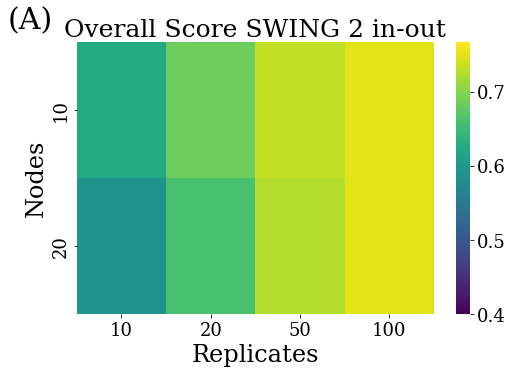

In [5]:
Nodes = [10,20]#,50]#,100]
data = []
in_degree = 2
for nodes in Nodes:  
    data.append([np.power(np.prod(AUROC[f"{algorithm}_{nodes}genes_{in_degree}_{replicates}replicates"]),1/100)/2 + np.power(np.prod(AUPRC[f"{algorithm}_{nodes}genes_{in_degree}_{replicates}replicates"]),1/100)/2 for replicates in Replicates ]) 

figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)

plt.rcParams["font.family"] = "serif"
sb.heatmap(data, cmap='viridis',vmin = 0.4, vmax=0.767,fmt="Mean AUROC")
plt.xticks([0.5,1.5,2.5,3.5],["10", "20", "50", "100"])
plt.yticks([0.5,1.5],["10","20"])
plt.ylabel('Nodes', family = 'serif',fontsize = 24)
plt.xlabel('Replicates', family = 'serif',fontsize = 24)
plt.title(f"Overall Score SWING {in_degree} in-out", fontsize = 25)
plt.text(-0.78,-0.1, "(A)", fontsize = 30)
plt.show()

## 3 in-out

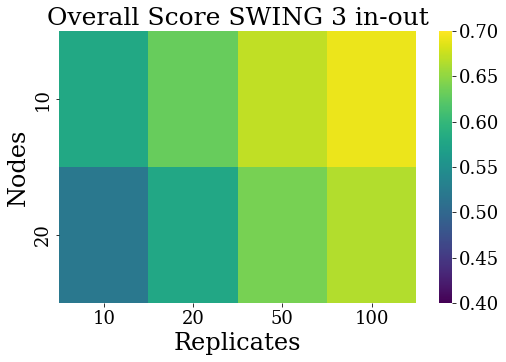

In [6]:
Nodes = [10,20]#,50]#,100]
data = []
in_degree = 3
for nodes in Nodes:  
    data.append([np.power(np.prod(AUROC[f"{algorithm}_{nodes}genes_{in_degree}_{replicates}replicates"]),1/100)/2 + np.power(np.prod(AUPRC[f"{algorithm}_{nodes}genes_{in_degree}_{replicates}replicates"]),1/100)/2 for replicates in Replicates ]) 

figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)

plt.rcParams["font.family"] = "serif"
sb.heatmap(data, cmap='viridis',vmin = 0.4, vmax=0.7,fmt="Mean AUROC")
plt.xticks([0.5,1.5,2.5,3.5],["10", "20", "50", "100"])
plt.yticks([0.5,1.5],["10","20"])
plt.ylabel('Nodes', family = 'serif',fontsize = 24)
plt.xlabel('Replicates', family = 'serif',fontsize = 24)
plt.title(f"Overall Score SWING {in_degree} in-out", fontsize = 25)
plt.show()

# 4 in-out

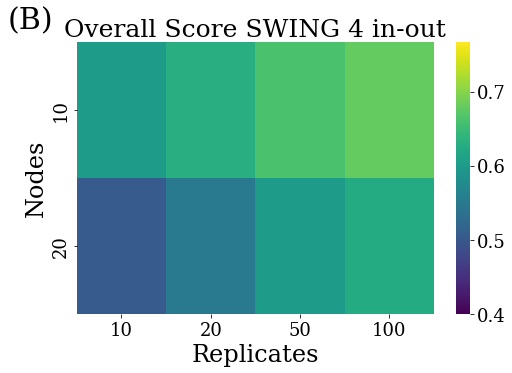

In [7]:
Nodes = [10,20]#,50]#,100]
data = []
in_degree = 4
for nodes in Nodes:  
    data.append([np.power(np.prod(AUROC[f"{algorithm}_{nodes}genes_{in_degree}_{replicates}replicates"]),1/100)/2 + np.power(np.prod(AUPRC[f"{algorithm}_{nodes}genes_{in_degree}_{replicates}replicates"]),1/100)/2 for replicates in Replicates ]) 

figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)

plt.rcParams["font.family"] = "serif"
sb.heatmap(data, cmap='viridis',vmin=0.4, vmax=0.767,fmt="Mean AUROC")
plt.xticks([0.5,1.5,2.5,3.5],["10", "20", "50", "100"])
plt.yticks([0.5,1.5],["10","20"])
plt.ylabel('Nodes', family = 'serif',fontsize = 24)
plt.xlabel('Replicates', family = 'serif',fontsize = 24)
plt.title(f"Overall Score SWING {in_degree} in-out", fontsize = 25)
plt.text(-0.78,-0.1, "(B)", fontsize = 30)
plt.show()
#plt.savefig("C:/Users/ivana/OneDrive/Desktop/Imagenes Internship/SWING_replicates_4degree.png", bbox_inches="tight", dpi=100)